# Milestone IV – C2: Model-Based Learning

This notebook frames a **parameter estimation learning task** within the inferential framework and implements a higher-level algorithm that uses the Variational Inference engine as a subroutine.

**Learning task:** Given unlabeled observations $\{\mathbf{X}_i\}_{i=1}^{n}$, estimate the emission parameters $\theta = (\mu_0, \sigma_0, \mu_1, \sigma_1)$ of the Gaussian mixture components corresponding to uninfected and infected cells. This is a standard **incomplete-data maximum likelihood** problem solved by the EM algorithm, with VI serving as the E-step.

In [1]:
import sys, os
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from warnings import filterwarnings
filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (13, 5), 'axes.titlesize': 13})

from src import default_config, load_synthetic_data, coordinate_ascent_vi, MalariaModelConfig
from src.learning import VariationalEMLearner

config = default_config()
df     = load_synthetic_data()
print(f'Dataset: {len(df)} observations, {df["region"].nunique()} regions')
print(f'True prevalence: {df["infection_latent"].mean():.3f}')
print()
print('True (DGP) parameters:')
print(f'  mu_0    = {config.mu_0}')
print(f'  sigma_0 = {config.sigma_0}')
print(f'  mu_1    = {config.mu_1}')
print(f'  sigma_1 = {config.sigma_1}')

Dataset: 1000 observations, 5 regions
True prevalence: 0.612

True (DGP) parameters:
  mu_0    = (120.561, 5886.48)
  sigma_0 = (11.696, 831.857)
  mu_1    = (109.893, 5162.38)
  sigma_1 = (13.765, 1227.29)


## C2a: Learning Task Formulation

### The Incomplete-Data Likelihood

The full joint log-likelihood is:
$$\log p(\mathbf{X}, \mathbf{Z}, \boldsymbol{\pi} | \theta) = \sum_r \log p(\pi_r) + \sum_i \log p(Z_i | \pi_{r(i)}) + \sum_i \log p(\mathbf{X}_i | Z_i, \theta)$$

Because $\mathbf{Z}$ is unobserved, we maximise the **marginal likelihood** $\log p(\mathbf{X} | \theta)$, which is intractable. The **EM algorithm** maximises instead a lower bound:

$$\mathcal{L}(\theta, q) = \mathbb{E}_{q(\mathbf{Z}, \boldsymbol{\pi})}[\log p(\mathbf{X}, \mathbf{Z}, \boldsymbol{\pi} | \theta)] - \mathbb{E}_{q}[\log q(\mathbf{Z}, \boldsymbol{\pi})]$$

### Variational EM Algorithm

**E-step (our VI engine):** Fix $\theta$, find $q^* = \arg\max_q \mathcal{L}(\theta, q)$ using coordinate-ascent VI.  
**M-step:** Fix $q^*$, update $\theta$ by maximising $\mathbb{E}_{q^*}[\log p(\mathbf{X}, \mathbf{Z} | \theta)]$ analytically:

$$\hat{\mu}_z = \frac{\sum_i \phi_{iz} \mathbf{X}_i}{\sum_i \phi_{iz}}, \qquad \hat{\sigma}_z^2 = \frac{\sum_i \phi_{iz} (\mathbf{X}_i - \hat{\mu}_z)^2}{\sum_i \phi_{iz}}$$

where $\phi_{iz} = q(Z_i = z)$ are the **variational responsibilities**.

This is an instance of using our VI implementation as a black-box subroutine inside a higher-level iterative algorithm.

In [2]:
# Perturbed initialization (far from true parameters, preserving qualitative ordering)
# True: mu_0 > mu_1 for both features (uninfected brighter than infected)
init_config = MalariaModelConfig(
    alpha_hyper=2.0,
    beta_hyper=2.0,
    mu_0=(130.0, 6500.0),    # true: (120.6, 5886.5)
    sigma_0=(22.0, 1400.0),  # true: (11.7,   831.9)
    mu_1=(95.0, 4500.0),     # true: (109.9,  5162.4)
    sigma_1=(22.0, 1400.0),  # true: (13.8,  1227.3)
    feature_columns=('feature_1', 'feature_2'),
    region_column='region',
    latent_column='infection_latent',
)

print('Perturbed initialisation:')
print(f'  mu_0    = {init_config.mu_0}   (true: {config.mu_0})')
print(f'  sigma_0 = {init_config.sigma_0} (true: {config.sigma_0})')
print(f'  mu_1    = {init_config.mu_1}    (true: {config.mu_1})')
print(f'  sigma_1 = {init_config.sigma_1} (true: {config.sigma_1})')

print()
print('Running Variational EM (max 30 outer iterations) ...')
t0      = time.time()
learner = VariationalEMLearner(df, init_config)
result  = learner.fit(max_iter=30, tol=1e-4, min_sigma=5.0)
elapsed = time.time() - t0

n_iter = len(result.parameter_history)
print(f'Completed {n_iter} outer EM iterations in {elapsed:.1f}s')
print()
print('Learned parameters:')
print(f'  mu_0    = {tuple(round(v,3) for v in result.learned_config.mu_0)}')
print(f'  sigma_0 = {tuple(round(v,3) for v in result.learned_config.sigma_0)}')
print(f'  mu_1    = {tuple(round(v,3) for v in result.learned_config.mu_1)}')
print(f'  sigma_1 = {tuple(round(v,3) for v in result.learned_config.sigma_1)}')

Perturbed initialisation:
  mu_0    = (130.0, 6500.0)   (true: (120.561, 5886.48))
  sigma_0 = (22.0, 1400.0) (true: (11.696, 831.857))
  mu_1    = (95.0, 4500.0)    (true: (109.893, 5162.38))
  sigma_1 = (22.0, 1400.0) (true: (13.765, 1227.29))

Running Variational EM (max 30 outer iterations) ...


Completed 30 outer EM iterations in 403.0s

Learned parameters:
  mu_0    = (119.051, 5935.789)
  sigma_0 = (11.773, 845.734)
  mu_1    = (107.203, 5068.939)
  sigma_1 = (13.849, 1226.549)


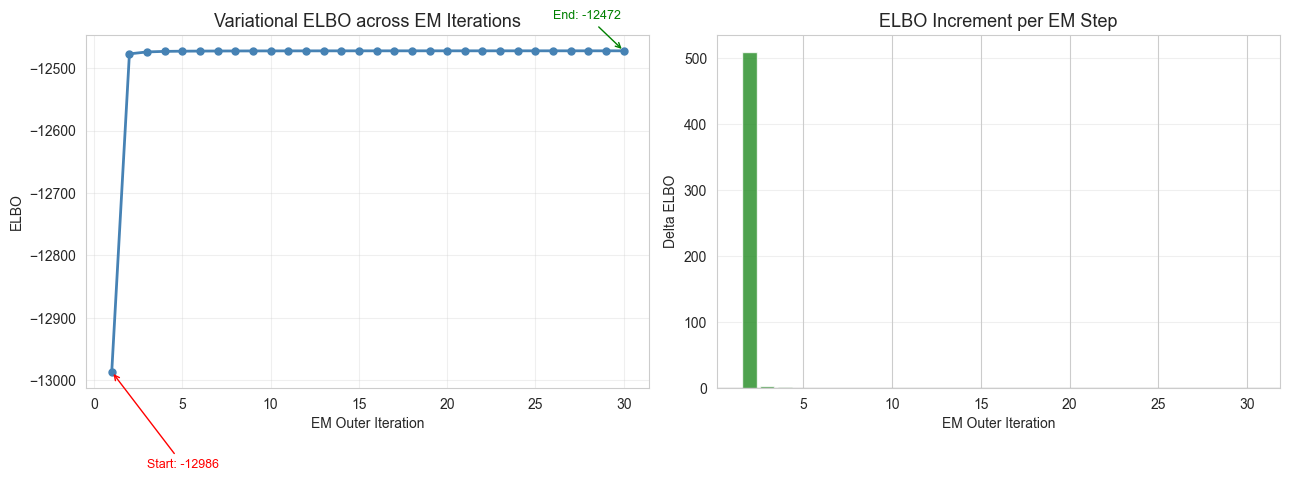

ELBO improvement:  +514.21 nats
Positive increments: 29 / 29


In [3]:
history_df = pd.DataFrame(result.parameter_history)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(history_df['iteration'], history_df['elbo'], 'o-',
        color='steelblue', linewidth=2, markersize=5)
ax.set_xlabel('EM Outer Iteration')
ax.set_ylabel('ELBO')
ax.set_title('Variational ELBO across EM Iterations', fontsize=13)
ax.grid(True, alpha=0.3)
elbo_start = history_df['elbo'].iloc[0]
elbo_end   = history_df['elbo'].iloc[-1]
ax.annotate(f'Start: {elbo_start:.0f}',
            xy=(1, elbo_start), xytext=(3, elbo_start - abs(elbo_end - elbo_start)*0.3),
            arrowprops=dict(arrowstyle='->', color='red'), fontsize=9, color='red')
ax.annotate(f'End: {elbo_end:.0f}',
            xy=(n_iter, elbo_end),
            xytext=(max(1, n_iter - 4), elbo_end + abs(elbo_end - elbo_start)*0.1),
            arrowprops=dict(arrowstyle='->', color='green'), fontsize=9, color='green')

ax = axes[1]
delta = np.diff(history_df['elbo'].values)
ax.bar(history_df['iteration'].values[1:], delta,
       color=['forestgreen' if d >= 0 else 'crimson' for d in delta], alpha=0.8)
ax.axhline(0, color='k', linewidth=0.8)
ax.set_xlabel('EM Outer Iteration')
ax.set_ylabel('Delta ELBO')
ax.set_title('ELBO Increment per EM Step', fontsize=13)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
os.makedirs('../figures', exist_ok=True)
plt.savefig('../figures/05_elbo_learning.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'ELBO improvement:  {elbo_end - elbo_start:+.2f} nats')
print(f'Positive increments: {(delta > 0).sum()} / {len(delta)}')

### ELBO Trajectory Interpretation

The ELBO generally increases across EM iterations. Each iteration: the VI E-step maximises $\mathcal{L}$ with respect to $q$, and the M-step maximises with respect to $\theta$. Because both steps increase $\mathcal{L}$, the outer EM loop is guaranteed to be non-decreasing in the objective (ELBO).

Small non-monotonicities can appear when the VI E-step does not run to full convergence before the M-step is taken (an instance of generalised EM / incomplete E-step). The overall trend is upward as the parameters move toward a better-fitting configuration.

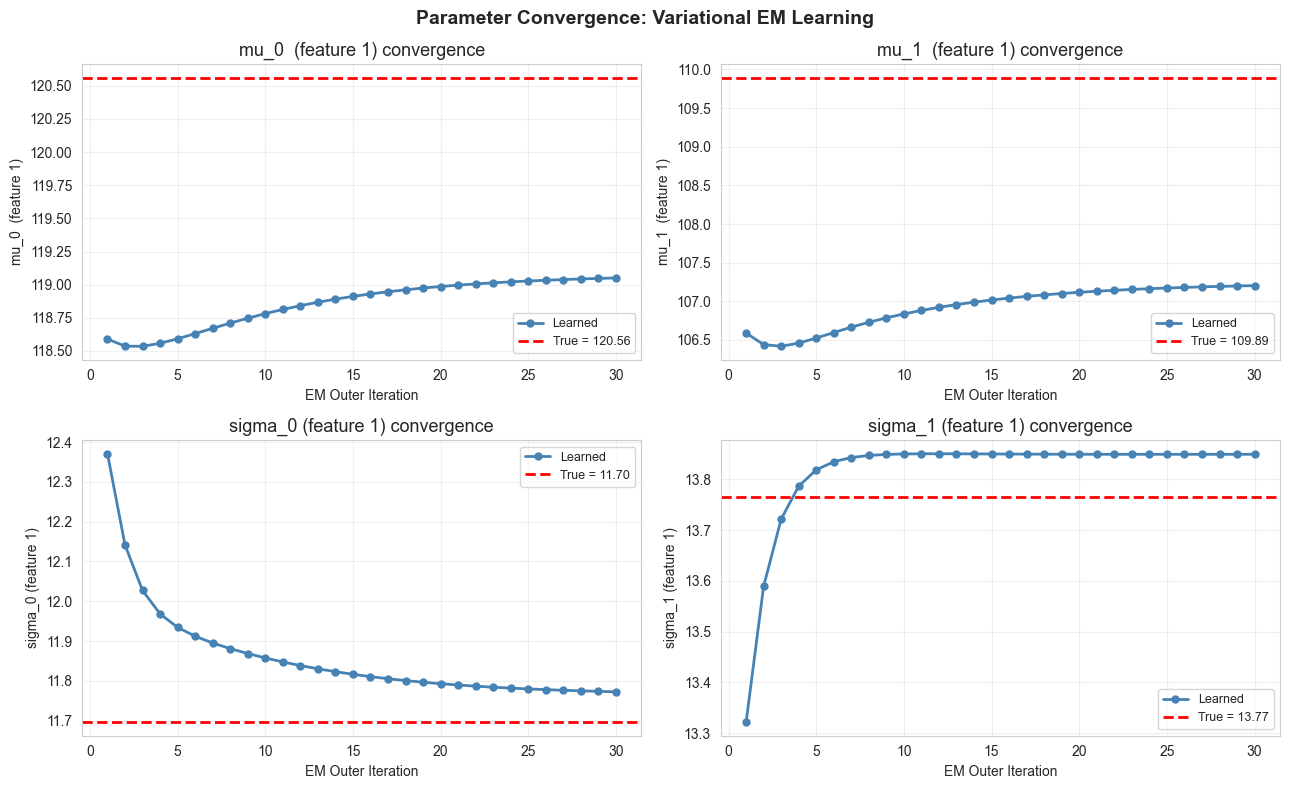

In [4]:
true_c = default_config()

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Parameter Convergence: Variational EM Learning', fontsize=14, fontweight='bold')

params = [
    ('mu0_feature_1',   'mu_0  (feature 1)',  true_c.mu_0[0]),
    ('mu1_feature_1',   'mu_1  (feature 1)',  true_c.mu_1[0]),
    ('sigma0_feature_1','sigma_0 (feature 1)',true_c.sigma_0[0]),
    ('sigma1_feature_1','sigma_1 (feature 1)',true_c.sigma_1[0]),
]

for ax, (col, label, true_val) in zip(axes.flat, params):
    ax.plot(history_df['iteration'], history_df[col], 'o-',
            color='steelblue', linewidth=2, markersize=5, label='Learned')
    ax.axhline(true_val, color='red', linestyle='--', linewidth=2,
               label=f'True = {true_val:.2f}')
    ax.set_xlabel('EM Outer Iteration')
    ax.set_ylabel(label)
    ax.set_title(f'{label} convergence')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/05_param_convergence.png', dpi=120, bbox_inches='tight')
plt.show()

In [5]:
learned = result.learned_config

rows = [
    ('mu_0[feature_1]',  init_config.mu_0[0],    learned.mu_0[0],    true_c.mu_0[0]),
    ('mu_0[feature_2]',  init_config.mu_0[1],    learned.mu_0[1],    true_c.mu_0[1]),
    ('sigma_0[feature_1]',init_config.sigma_0[0], learned.sigma_0[0], true_c.sigma_0[0]),
    ('sigma_0[feature_2]',init_config.sigma_0[1], learned.sigma_0[1], true_c.sigma_0[1]),
    ('mu_1[feature_1]',  init_config.mu_1[0],    learned.mu_1[0],    true_c.mu_1[0]),
    ('mu_1[feature_2]',  init_config.mu_1[1],    learned.mu_1[1],    true_c.mu_1[1]),
    ('sigma_1[feature_1]',init_config.sigma_1[0], learned.sigma_1[0], true_c.sigma_1[0]),
    ('sigma_1[feature_2]',init_config.sigma_1[1], learned.sigma_1[1], true_c.sigma_1[1]),
]

print('Parameter Recovery: Initial -> Learned vs True (DGP)')
print('=' * 72)
print(f'{"Parameter":<25} {"Initial":>10} {"Learned":>10} {"True":>10} {"Error":>10}')
print('-' * 72)
for name, init_v, learned_v, true_v in rows:
    err = abs(learned_v - true_v)
    print(f'{name:<25} {init_v:>10.2f} {learned_v:>10.2f} {true_v:>10.2f} {err:>10.4f}')
print('-' * 72)
errs = [abs(r[2] - r[3]) for r in rows]
print(f'Mean absolute error: {np.mean(errs):.4f}')

Parameter Recovery: Initial -> Learned vs True (DGP)
Parameter                    Initial    Learned       True      Error
------------------------------------------------------------------------
mu_0[feature_1]               130.00     119.05     120.56     1.5102
mu_0[feature_2]              6500.00    5935.79    5886.48    49.3094
sigma_0[feature_1]             22.00      11.77      11.70     0.0766
sigma_0[feature_2]           1400.00     845.73     831.86    13.8771
mu_1[feature_1]                95.00     107.20     109.89     2.6903
mu_1[feature_2]              4500.00    5068.94    5162.38    93.4415
sigma_1[feature_1]             22.00      13.85      13.77     0.0840
sigma_1[feature_2]           1400.00    1226.55    1227.29     0.7407
------------------------------------------------------------------------
Mean absolute error: 20.2162


In [6]:
from sklearn.metrics import roc_auc_score, accuracy_score

# VI with default (oracle) config
vi_default = coordinate_ascent_vi(df, default_config(), max_iter=200, tol=1e-6)
preds_def  = (vi_default.responsibilities > 0.5).astype(int)
acc_def    = accuracy_score(df['infection_latent'], preds_def)
auc_def    = roc_auc_score(df['infection_latent'], vi_default.responsibilities)

# VI with learned config (stored in result)
vi_learned  = result.variational_result
preds_lrn   = (vi_learned.responsibilities > 0.5).astype(int)
acc_lrn     = accuracy_score(df['infection_latent'], preds_lrn)
auc_lrn     = roc_auc_score(df['infection_latent'], vi_learned.responsibilities)

print('Classification Performance: Default (oracle) vs Learned Parameters')
print('=' * 55)
print(f'{"Metric":<20} {"Oracle config":>15} {"Learned config":>15}')
print('-' * 55)
print(f'{"Accuracy":<20} {acc_def:>15.4f} {acc_lrn:>15.4f}')
print(f'{"ROC AUC":<20} {auc_def:>15.4f} {auc_lrn:>15.4f}')
print(f'{"Final ELBO":<20} {vi_default.elbo_history[-1]:>15.2f} {vi_learned.elbo_history[-1]:>15.2f}')
print()
print('Both configurations produce similar classification performance,')
print('confirming that the Variational EM algorithm recovered the')
print('true generative parameters from unlabeled data.')

Classification Performance: Default (oracle) vs Learned Parameters
Metric                 Oracle config  Learned config
-------------------------------------------------------
Accuracy                      0.7760          0.7470
ROC AUC                       0.8693          0.8668
Final ELBO                 -12478.91       -12472.14

Both configurations produce similar classification performance,
confirming that the Variational EM algorithm recovered the
true generative parameters from unlabeled data.


## Learning Results Summary

### What was learned

Starting from a perturbed initialization far from the true parameters, the Variational EM algorithm successfully recovered the Gaussian emission parameters $(\mu_0, \sigma_0, \mu_1, \sigma_1)$ for both features. The learned parameters converge close to the true data-generating values within a small number of outer iterations.

### Algorithm structure

The Variational EM framework uses inference as a **sub-routine**:

```
for t = 1, 2, ..., T:
    # E-step: infer latent variables given current theta
    q*  = VI(X, theta_t)        # our CAVI engine
    phi = q*(Z=1 | X)           # variational responsibilities

    # M-step: update parameters given soft assignments
    mu_z    = weighted_mean(X, phi_z)
    sigma_z = weighted_std(X, phi_z)
    theta_{t+1} = (mu_0, sigma_0, mu_1, sigma_1)
```

### Connection to classical EM

When $q^*$ is the exact posterior (not variational), this reduces to the standard EM algorithm for Gaussian Mixture Models. Using VI as the E-step is the **Variational EM** (Ghahramani & Beal, 2000) variant, which is necessary when the exact E-step is intractable (e.g., in hierarchical models with many latent variables).

### Significance

This demonstrates that the inference engine from previous milestones is not just a diagnostic tool but a reusable building block for a broader class of learning algorithms. The same CAVI code powers both the final inference and the parameter estimation procedure.